In [87]:
import numpy as np
import pandas as pd
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import NearestNeighbors
import os
import json

In [88]:
df= pd.read_csv("../../data/processed/parking_violations_clean.csv")

In [89]:
coords = np.radians(df[['latitude', 'longitude']].values)

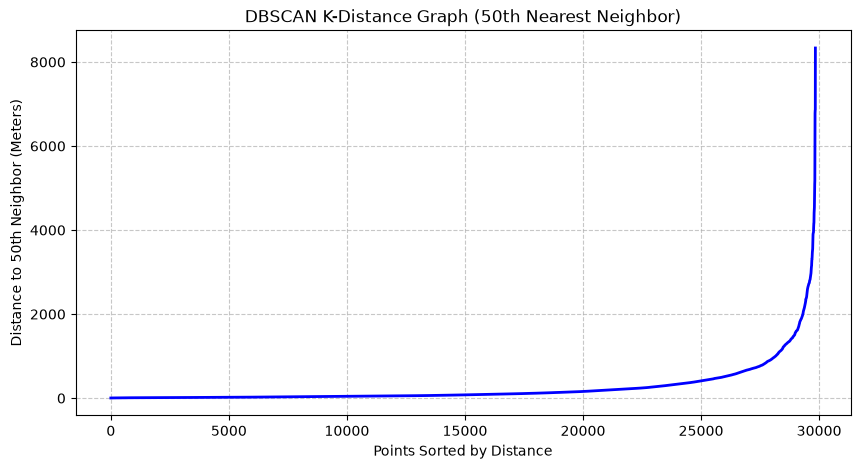

In [90]:
df_sample = df.sample(frac=0.1, random_state=42).copy()

coords_sample = np.radians(df_sample[['latitude', 'longitude']].values)

neighbors = NearestNeighbors(n_neighbors=50, metric='haversine', n_jobs=-1)
neighbors_fit = neighbors.fit(coords_sample)
distances, indices = neighbors_fit.kneighbors(coords_sample)

sort_distances = np.sort(distances[:, -1]) * 6371008.8

plt.figure(figsize=(10, 5))
plt.plot(sort_distances, color='blue', lw=2)
plt.title("DBSCAN K-Distance Graph (50th Nearest Neighbor)")
plt.xlabel("Points Sorted by Distance")
plt.ylabel("Distance to 50th Neighbor (Meters)")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [91]:
EPS_RADIUS_METERS = 100
MIN_VEHICLES = 50
eps_radians = (EPS_RADIUS_METERS / 1000.0) / 6371.0088

In [92]:
db = DBSCAN(
    eps=eps_radians, 
    min_samples=MIN_VEHICLES, 
    metric='haversine', 
    n_jobs=-1
)

In [93]:
df['cluster_id'] = db.fit_predict(coords)

n_clusters = len(set(df['cluster_id'])) - (1 if -1 in df['cluster_id'] else 0)
n_noise = (df['cluster_id'] == -1).sum()

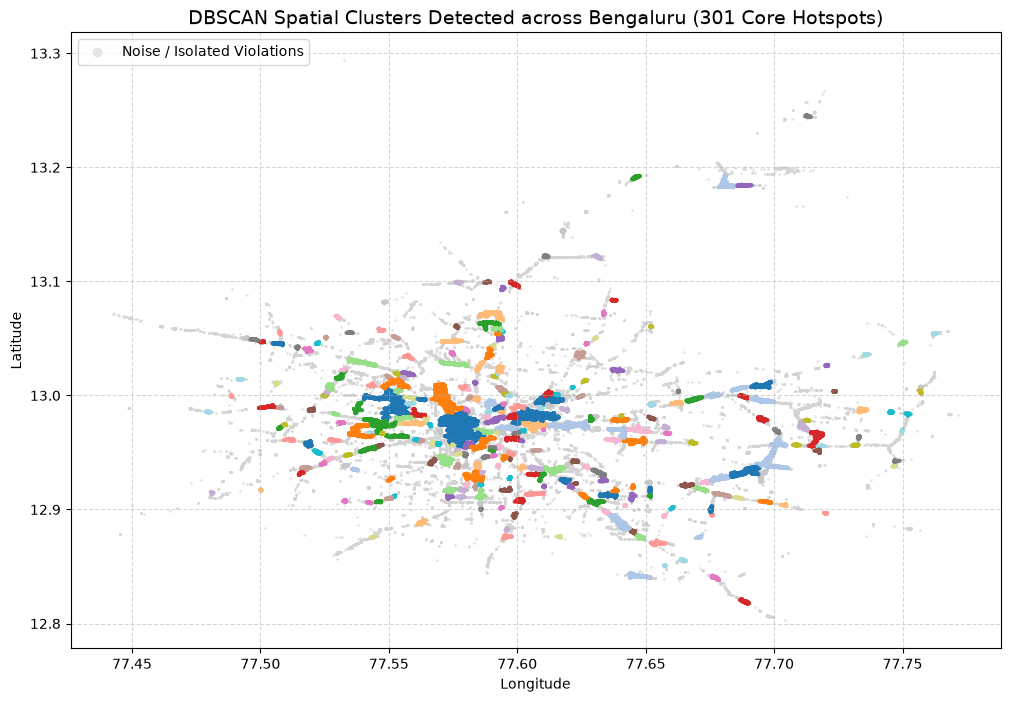

In [94]:
plt.figure(figsize=(12, 8))
df_noise = df[df['cluster_id'] == -1]
plt.scatter(
    df_noise['longitude'], df_noise['latitude'], 
    c='lightgray', s=1, alpha=0.5, label='Noise / Isolated Violations'
)
df_valid_clusters = df[df['cluster_id'] != -1]
scatter = plt.scatter(
    df_valid_clusters['longitude'], df_valid_clusters['latitude'], 
    c=df_valid_clusters['cluster_id'], cmap='tab20', s=4, alpha=0.8
)

plt.title(f"DBSCAN Spatial Clusters Detected across Bengaluru ({n_clusters} Core Hotspots)", fontsize=14)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(markerscale=6, loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

In [95]:
df_exploded=pd.read_csv('../../data/processed/parking_violations_exploded.csv')

In [96]:
cluster_mapping = df.set_index('id')['cluster_id']
df_exploded['cluster_id'] = df_exploded['id'].map(cluster_mapping)

In [97]:
df_clusters = df_exploded[df_exploded['cluster_id'] != -1].copy()

In [98]:
VIOLATION_SEVERITY = {
    "DOUBLE PARKING": 2.0,
    "PARKING IN A MAIN ROAD": 2.0,
    "PARKING ON FOOTPATH": 1.5,
    "PARKING OPPOSITE TO ANOTHER PARKED VEHICLE": 1.8,
    "NO PARKING": 1.0,
    "WRONG PARKING": 1.0,
    "PARKING NEAR BUSTOP/SCHOOL/HOSPITAL ETC": 1.5,
    "PARKING NEAR ROAD CROSSING": 1.7,
    "PARKING NEAR TRAFFIC LIGHT OR ZEBRA CROSS": 1.9,
    "PARKING OTHER THAN BUS STOP": 1.2
}

df_clusters['violation_severity_weight'] = df_clusters['violation_type'].map(VIOLATION_SEVERITY).fillna(1.0)
df_clusters['base_impact'] = df_clusters['vehicle_footprint_weight'] * df_clusters['violation_severity_weight']
df_clusters['cdt_hour_bucket'] = (df_clusters['cdt_minute_of_day'] // 60).astype(int)

In [99]:
cluster_summary = df_clusters.groupby('cluster_id').agg(
    center_latitude=('latitude', 'mean'),
    center_longitude=('longitude', 'mean'),
    total_incident_count=('id', 'nunique'),
    raw_impact_score=('base_impact', 'sum'),
    representative_junction=('junction_name', lambda x: x.mode()[0] if not x.mode().empty else "Unknown Junction"),
    police_station_jurisdiction=('police_station', lambda x: x.mode()[0] if not x.mode().empty else "UNKNOWN PS")
).reset_index()

log_score = np.log1p(cluster_summary['raw_impact_score'])
cluster_summary['congestion_impact_score'] = (
    (log_score - log_score.min()) / (log_score.max() - log_score.min()) * 100
).round(1)

pct_rank = cluster_summary['raw_impact_score'].rank(pct=True)
def assign_priority(percentile):
    if percentile >= 0.90: return "CRITICAL"  
    if percentile >= 0.70: return "HIGH"      
    if percentile >= 0.40: return "MEDIUM"    
    return "LOW"
cluster_summary['priority_level'] = pct_rank.apply(assign_priority)

In [100]:
df['cluster_id'] = df['id'].map(cluster_mapping)
df_valid_events = df[df['cluster_id'] != -1].copy()
df_valid_events['cdt_hour_bucket'] = (df_valid_events['cdt_minute_of_day'] // 60).astype(int)

def get_smoothed_bimodal_peaks(group):
    morning_sub = group[group['cdt_hour_bucket'].between(7, 12)]
    evening_sub = group[group['cdt_hour_bucket'].between(16, 21)]
    
    m_peak = morning_sub.groupby('cdt_hour_bucket')['vehicle_number'].nunique().idxmax() if not morning_sub.empty else 9
    e_peak = evening_sub.groupby('cdt_hour_bucket')['vehicle_number'].nunique().idxmax() if not evening_sub.empty else 18
        
    return pd.Series([m_peak, e_peak], index=['morning_peak_hour', 'evening_peak_hour'])

fixed_peaks = df_valid_events.groupby('cluster_id').apply(get_smoothed_bimodal_peaks, include_groups=False).reset_index()

def hour_to_time_str(hour_val):
    am_pm = "AM" if hour_val < 12 else "PM"
    display_h = hour_val if 0 < hour_val <= 12 else (hour_val - 12 if hour_val > 12 else 12)
    return f"{display_h:02d}:00 {am_pm}"

fixed_peaks['morning_peak_string'] = fixed_peaks['morning_peak_hour'].apply(hour_to_time_str)
fixed_peaks['evening_peak_string'] = fixed_peaks['evening_peak_hour'].apply(hour_to_time_str)

cluster_summary = cluster_summary.merge(fixed_peaks, on='cluster_id')

def fix_no_junction_names(row):
    if row['representative_junction'] == "No Junction":
        cluster_data = df_clusters[df_clusters['cluster_id'] == row['cluster_id']]
        valid_locations = cluster_data['location'].dropna()
        if not valid_locations.empty and not valid_locations.mode().empty:
            top_loc = valid_locations.mode()[0]
            return f"{top_loc.split(',')[0]} Area"
    return row['representative_junction']

cluster_summary['representative_junction'] = cluster_summary.apply(fix_no_junction_names, axis=1)
cluster_summary['cluster_name'] = cluster_summary['representative_junction'] + " Cluster Hub"

cluster_summary.to_csv("../../data/processed/cluster_summary_checkpoint.csv", index=False)

In [101]:
summary_export_df = cluster_summary[[
    'cluster_id', 'cluster_name', 'center_latitude', 'center_longitude', 
    'representative_junction', 'police_station_jurisdiction', 
    'congestion_impact_score', 'total_incident_count', 'priority_level',
    'morning_peak_string', 'evening_peak_string'
]].sort_values(by='congestion_impact_score', ascending=False)

hotspots_summary_list = summary_export_df.to_dict(orient='records')

hotspots_details_dict = {}
has_updated_vt = 'updated_vehicle_type' in df_clusters.columns

for cid in cluster_summary['cluster_id'].unique():
    cluster_data = df_clusters[df_clusters['cluster_id'] == cid]
    total_incidents = len(cluster_data)
    
    if has_updated_vt:
        v_series = cluster_data['updated_vehicle_type'].fillna(cluster_data['vehicle_type'])
    else:
        v_series = cluster_data['vehicle_type']
        
    v_counts = v_series.value_counts()
    v_comp = {str(k): round(float(v) / total_incidents, 2) for k, v in v_counts.items()}
    
    violation_counts = cluster_data['violation_type'].value_counts()
    top_vils = []
    for v_type, count in violation_counts.head(3).items():
        top_vils.append({
            "type": str(v_type),
            "count": int(count),
            "percentage": round(float(count) / total_incidents, 2)
        })
        
    m_peak = int(cluster_summary[cluster_summary['cluster_id'] == cid]['morning_peak_hour'].values[0])
    e_peak = int(cluster_summary[cluster_summary['cluster_id'] == cid]['evening_peak_hour'].values[0])
    
    m_count = len(cluster_data[cluster_data['cdt_hour_bucket'] == m_peak])
    e_count = len(cluster_data[cluster_data['cdt_hour_bucket'] == e_peak])
    other_count = total_incidents - (m_count + e_count)
    
    temporal_dist = {
        "morning_peak_percentage": round(m_count / total_incidents, 2),
        "evening_peak_percentage": round(e_count / total_incidents, 2),
        "off_peak_percentage": round(max(0, other_count) / total_incidents, 2)
    }
    
    avg_processing = float(cluster_data['record_lifecycle_minutes_capped_p95'].mean()) if 'record_lifecycle_minutes_capped_p95' in cluster_data.columns else 0.0
    sync_count = int(cluster_data['data_sent_to_scita'].sum()) if 'data_sent_to_scita' in cluster_data.columns else 0
    
    hotspots_details_dict[str(cid)] = {
        "vehicle_composition": v_comp,
        "top_violations": top_vils,
        "temporal_distribution": temporal_dist,
        "operational_metrics": {
            "avg_ticket_processing_minutes": round(avg_processing, 1),
            "scita_sync_rate": round(sync_count / total_incidents, 2) if total_incidents > 0 else 0.0
        }
    }

with open("../../data/processed/hotspots_summary.json", "w") as f:
    json.dump(hotspots_summary_list, f, indent=2)

with open("../../data/processed/hotspots_details.json", "w") as f:
    json.dump(hotspots_details_dict, f, indent=2)

print("\nSample Preview of Top Hotspots:")
print(summary_export_df[['cluster_id', 'cluster_name', 'morning_peak_string', 'evening_peak_string', 'congestion_impact_score', 'priority_level']].head(10))


Sample Preview of Top Hotspots:
    cluster_id                                    cluster_name  \
2            2         BTP082 - KR Market Junction Cluster Hub   
3            3      BTP051 - Safina Plaza Junction Cluster Hub   
10          10       New Horizon College Road Area Cluster Hub   
5            5       BTP027 - Modi Bridge Junction Cluster Hub   
17          17     Kadubeesanahalli Underpass Area Cluster Hub   
33          33              80 Feet Ring Road Area Cluster Hub   
34          34  Sri Venkataranga Ayangar Road Area Cluster Hub   
25          25                   Unnamed Road Area Cluster Hub   
71          71                       MBT Road Area Cluster Hub   
7            7                       MBT Road Area Cluster Hub   

   morning_peak_string evening_peak_string  congestion_impact_score  \
2             09:00 AM            09:00 PM                    100.0   
3             10:00 AM            05:00 PM                     88.5   
10            08:00 AM     

In [102]:
df.to_csv("../../data/processed/parking_violations_with_clusters.csv", index=False)
df_clusters.to_csv("../../data/processed/parking_violations_exploded_with_clusters.csv", index=False)

### There were major mid night Outliers which were fixed due to cameras mass dumping data at night

### 75-90% of all Vehicles that are Ticketed were unique